# **Assessing Hydrological Drivers In Alpine Catchments Using Interpretable Machine Learning**



The hydrological response of Alpine catchments is complex and non-linear,
as it depends on several interacting climatic and topographic factors.
Understanding how these factors interact is critical for water resource (i.e., hydropower) and risk management, as well as assessing the impacts of climate change on Alpine hydrology.
Machine learning offers a data-driven approach that can capture these complex and non-linear relationships.
For this project, the main objectives are:
*   to predict river flow based on meteorological and topographical predictors, and
*   to quantify and interpret the importance of these variables in different Alpine river basins.

## **Import Libraries and Tools**

In [2]:
# Files handling
import os
import glob

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

# Colab integration (Google Drive access)
from google.colab import drive
drive.mount('/content/drive')

# ML tools
from sklearn.model_selection import train_test_split, GroupKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance

# Evaluation metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, make_scorer
from scipy.stats import randint

# Save model
import joblib
import pickle

Mounted at /content/drive


## **Import Data**

In [3]:
# Base directory where the dataset is stored on Google Drive
base_dir = "/content/drive/MyDrive/ML/project/data"

# Paths to different files
streamflow_path_pattern = f"{base_dir}/timeseries/observation_based/CAMELS_CH_obs_based_*.csv"
topo_path = f"{base_dir}/static_attributes/CAMELS_CH_topographic_attributes.csv"
glacier_path = f"{base_dir}/annual_timeseries/CAMELS_CH_annual_data_*.csv"

# Loading static attribute datasets
topo_df = pd.read_csv(topo_path, usecols=["gauge_id", "area", "elev_mean", "elev_min", "elev_max", "slope_mean"],comment="#", encoding='latin1')

# Loading all timeseries files
streamflow_files = glob.glob(streamflow_path_pattern)
glacier_files = glob.glob(glacier_path)

# Preview loaded files
print("Number of streamflow files loaded:", len(streamflow_files))
print("Number of glacier files loaded:", len(glacier_files))
print("Static topo attributes:", topo_df.shape)

Number of streamflow files loaded: 331
Number of glacier files loaded: 331
Static topo attributes: (331, 6)


## **Dataset Preparation**

In [4]:
# Selecting only the catchments of interest based on their IDs
catchments = ["2161", "2420","2351"]

In [5]:
# Filtering streamflow files by selected basins
selected_files_sf = [
    fp for fp in streamflow_files
    if os.path.basename(fp).split("_")[-1].split(".")[0] in catchments
]

# Reading and combining selected time series into one DataFrame
streamflow_list = []
for file_path in selected_files_sf:
    basin_id = os.path.basename(file_path).split("_")[-1].split(".")[0]
    df = pd.read_csv(file_path, usecols=["date", "discharge_vol(m3/s)", "precipitation(mm/d)", "temperature_min(degC)", "temperature_mean(degC)", "temperature_max(degC)", "rel_sun_dur(%)", "swe(mm)"], parse_dates=["date"])
    df["basin_id"] = basin_id
    streamflow_list.append(df)

streamflow_df = pd.concat(streamflow_list, ignore_index=True)

In [6]:
# Filtering glacier files by selected basins
selected_files_g = [
    g for g in glacier_files
    if os.path.basename(g).split("_")[-1].split(".")[0] in catchments
]

# Reading and combining selected time series into one DataFrame
glacier_list = []
for file_path in selected_files_g:
    basin_id = os.path.basename(file_path).split("_")[-1].split(".")[0]
    df = pd.read_csv(file_path, usecols=["year", "glac_area_ch(km2)", "glac_vol_ch(km3)", "glac_mass_ch(Mt)"], comment="#", parse_dates=["year"])
    df["basin_id"] = basin_id
    glacier_list.append(df)

glacier_df = pd.concat(glacier_list, ignore_index=True)

In [7]:
# Making sure basin IDs are strings before merging
topo_df["gauge_id"] = topo_df["gauge_id"].astype(str)
glacier_df["basin_id"] = glacier_df["basin_id"].astype(str)
streamflow_df["basin_id"] = streamflow_df["basin_id"].astype(str)

In [8]:
# Renaming gauge_id to match basin_id
topo_df = topo_df.rename(columns={"gauge_id": "basin_id"})

In [9]:
# Keeping only selected basins for static data
topo_df = topo_df[topo_df["basin_id"].isin(catchments)]

In [10]:
# Extracting year from streamflow_df (daily) for merging with glacier_df (annual)
streamflow_df['year'] = streamflow_df['date'].dt.year

# Ensuring year column in glacier_df is also an integer year for consistent merging
glacier_df['year'] = glacier_df['year'].dt.year

# Merging streamflow data with glacier data on basin_id and year
merged_time_series_df = pd.merge(streamflow_df, glacier_df, on=['basin_id', 'year'], how='left')

# Merging time series with static topographic attributes on basin_id
final_df = pd.merge(merged_time_series_df, topo_df, on='basin_id', how='left')

# Filtering the dataset for the 1999-2020 period
final_df = final_df[(final_df['year'] >= 1999)]

In [11]:
# Dataset overview
print("Shape:", final_df.shape)

# Column types
print("\nData types:")
print(final_df.dtypes)

# Summary of numerical columns
print("\nSummary:")
display(final_df.head())

# Missing value check
print("\nMissing values per column:")
print(final_df.isnull().sum())

Shape: (24108, 18)

Data types:
date                      datetime64[ns]
discharge_vol(m3/s)              float64
precipitation(mm/d)              float64
temperature_min(degC)            float64
temperature_mean(degC)           float64
temperature_max(degC)            float64
rel_sun_dur(%)                   float64
swe(mm)                          float64
basin_id                          object
year                               int32
glac_area_ch(km2)                float64
glac_vol_ch(km3)                 float64
glac_mass_ch(Mt)                 float64
area                             float64
elev_mean                        float64
elev_min                         float64
elev_max                         float64
slope_mean                       float64
dtype: object

Summary:


,date,discharge_vol(m3/s),precipitation(mm/d),temperature_min(degC),temperature_mean(degC),temperature_max(degC),rel_sun_dur(%),swe(mm),basin_id,year,glac_area_ch(km2),glac_vol_ch(km3),glac_mass_ch(Mt),area,elev_mean,elev_min,elev_max,slope_mean
6574,1999-01-01,0.340,0.16,-10.53,-9.45,-7.21,0.20,474.0,2161,1999,118.1677,15.5305,13200.928,195.5,2929.36,1472.64,4088.8,23.32
6575,1999-01-02,0.336,2.15,-10.05,-8.52,-5.90,27.83,477.0,2161,1999,118.1677,15.5305,13200.928,195.5,2929.36,1472.64,4088.8,23.32
6576,1999-01-03,0.341,14.53,-12.70,-9.87,-6.22,0.15,478.0,2161,1999,118.1677,15.5305,13200.928,195.5,2929.36,1472.64,4088.8,23.32
6577,1999-01-04,0.342,0.21,-10.75,-4.62,-1.70,69.17,489.0,2161,1999,118.1677,15.5305,13200.928,195.5,2929.36,1472.64,4088.8,23.32
6578,1999-01-05,0.339,0.00,-2.83,0.46,3.18,83.51,490.0,2161,1999,118.1677,15.5305,13200.928,195.5,2929.36,1472.64,4088.8,23.32



Missing values per column:
date                      0
discharge_vol(m3/s)       0
precipitation(mm/d)       0
temperature_min(degC)     0
temperature_mean(degC)    0
temperature_max(degC)     0
rel_sun_dur(%)            0
swe(mm)                   0
basin_id                  0
year                      0
glac_area_ch(km2)         0
glac_vol_ch(km3)          0
glac_mass_ch(Mt)          0
area                      0
elev_mean                 0
elev_min                  0
elev_max                  0
slope_mean                0
dtype: int64


## **Data Preprocessing**

In [12]:
final_df = final_df.sort_values(['basin_id', 'date'])

## Computing icemelt index

# Computing day of the year (doy)
final_df["doy"] = final_df["date"].dt.dayofyear
final_df["doy"] = final_df["doy"].astype(int)

# Computing glacier area fraction
final_df["glacier_area_frac"] = final_df["glac_area_ch(km2)"] / final_df["area"]

# Computing melt potential
final_df["pdd"] = np.maximum(final_df['temperature_mean(degC)'],0)
final_df["rad_fac"] = 1 + final_df["rel_sun_dur(%)"] / 100
final_df["melt_potential"] = final_df["pdd"] * final_df["rad_fac"]

# Computing melt seasonality according to climate-driven
def normalize_series(x):
    rng = x.max() - x.min()
    if rng == 0:
        return np.zeros_like(x)
    return (x - x.min()) / rng

final_df["s_doy_year"] = (
    final_df
    .groupby(["basin_id", "year"])["melt_potential"]
    .transform(normalize_series)
)

final_df["s_doy_year"] = final_df["s_doy_year"].fillna(0)

# Computing the icemelt index
final_df["ice_melt_index_year"] = (
    final_df["melt_potential"] *
    final_df["glacier_area_frac"] *
    final_df["s_doy_year"])

# Visualizing final dataset after data preprocessing
final_df.head()


,date,discharge_vol(m3/s),precipitation(mm/d),temperature_min(degC),temperature_mean(degC),temperature_max(degC),rel_sun_dur(%),swe(mm),basin_id,year,...,elev_min,elev_max,slope_mean,doy,glacier_area_frac,pdd,rad_fac,melt_potential,s_doy_year,ice_melt_index_year
6574,1999-01-01,0.340,0.16,-10.53,-9.45,-7.21,0.20,474.0,2161,1999,...,1472.64,4088.8,23.32,1,0.604438,0.00,1.0020,0.000000,0.000000,0.000000
6575,1999-01-02,0.336,2.15,-10.05,-8.52,-5.90,27.83,477.0,2161,1999,...,1472.64,4088.8,23.32,2,0.604438,0.00,1.2783,0.000000,0.000000,0.000000
6576,1999-01-03,0.341,14.53,-12.70,-9.87,-6.22,0.15,478.0,2161,1999,...,1472.64,4088.8,23.32,3,0.604438,0.00,1.0015,0.000000,0.000000,0.000000
6577,1999-01-04,0.342,0.21,-10.75,-4.62,-1.70,69.17,489.0,2161,1999,...,1472.64,4088.8,23.32,4,0.604438,0.00,1.6917,0.000000,0.000000,0.000000
6578,1999-01-05,0.339,0.00,-2.83,0.46,3.18,83.51,490.0,2161,1999,...,1472.64,4088.8,23.32,5,0.604438,0.46,1.8351,0.844146,0.044497,0.022704


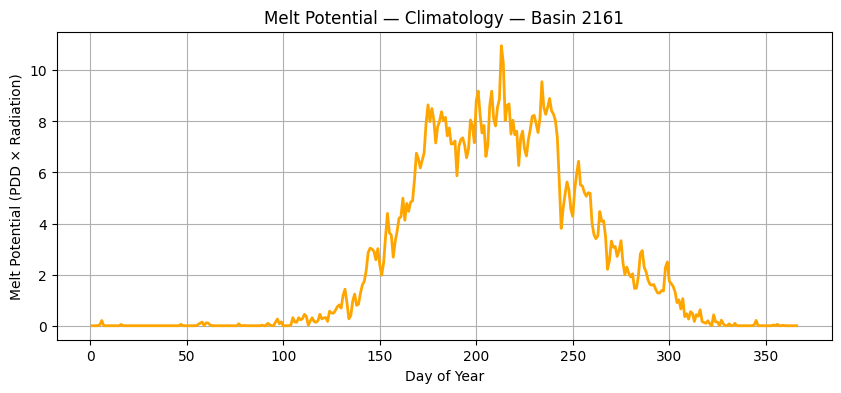

In [13]:
import matplotlib.pyplot as plt

basin = "2161"
dfb = final_df[final_df["basin_id"] == basin].copy()
dfb["doy"] = dfb["date"].dt.dayofyear

# Climatology
mp_clim = dfb.groupby("doy")["melt_potential"].mean()

plt.figure(figsize=(10,4))
plt.plot(mp_clim.index, mp_clim.values, color="orange", linewidth=2)
plt.title(f"Melt Potential — Climatology — Basin {basin}")
plt.xlabel("Day of Year")
plt.ylabel("Melt Potential (PDD × Radiation)")
plt.grid(True)
plt.show()


## **Predictor and Target Variable Selection**

In [15]:
# Selecting predictors
predictors = ["precipitation(mm/d)",
              "temperature_min(degC)",
              "temperature_mean(degC)",
              "temperature_max(degC)",
              "rel_sun_dur(%)",
              "swe(mm)",
              "glac_area_ch(km2)",
              "glac_vol_ch(km3)",
              "glac_mass_ch(Mt)",
              "area",
              "elev_mean",
              "elev_min",
              "elev_max",
              "slope_mean",
              "melt_potential",
              "s_doy_year",
              "ice_melt_index_year",
              "doy",
              "year",
              "glacier_area_frac"
]

# Defining X, y and groups for cross-validation
X = final_df[predictors]
y = final_df["discharge_vol(m3/s)"]

## **Temporal Split**

In [15]:
# Sorting data
data = final_df.sort_values(["basin_id", "date"]).reset_index(drop=True)

train_idx = []
val_idx = []
test_idx = []

# Looping over basins
for basin in data["basin_id"].unique():

    basin_df = data[data["basin_id"] == basin]

    # Looping over every year-month combination
    for (yr, mo), df_month in basin_df.groupby([basin_df["date"].dt.year,
                                                basin_df["date"].dt.month]):

        df_month = df_month.sort_values("date")
        n = len(df_month)

        # Standard 20–5–5 or adjusted for shorter months
        if n >= 30:
            n_train = 20
            n_val = 5
            n_test = 5
        elif n == 29:
            n_train = 19
            n_val = 5
            n_test = 5
        elif n == 28:
            n_train = 18
            n_val = 5
            n_test = 5

        # Extracting indices
        idx_train = df_month.iloc[:n_train].index
        idx_val   = df_month.iloc[n_train:n_train + n_val].index
        idx_test  = df_month.iloc[n_train + n_val:n_train + n_val + n_test].index

        train_idx.extend(idx_train)
        val_idx.extend(idx_val)
        test_idx.extend(idx_test)

# Creating again X and y from the 'data' DataFrame, which has the reset index.
X = data[predictors]
y = data["discharge_vol(m3/s)"]

# Final splitting
X_train, y_train = X.loc[train_idx], y.loc[train_idx]
X_val,   y_val   = X.loc[val_idx],   y.loc[val_idx]
X_test,  y_test  = X.loc[test_idx],  y.loc[test_idx]


# Checking dimensions and correct splitting
print("Train size:", len(X_train))
print("Validation size:", len(X_val))
print("Test size:", len(X_test))

print(data.loc[train_idx, "date"].min(), data.loc[train_idx, "date"].max())
print(data.loc[val_idx,   "date"].min(), data.loc[val_idx,   "date"].max())
print(data.loc[test_idx,  "date"].min(), data.loc[test_idx,  "date"].max())



Train size: 15726
Validation size: 3960
Test size: 3960
1999-01-01 00:00:00 2020-12-20 00:00:00
1999-01-21 00:00:00 2020-12-25 00:00:00
1999-01-26 00:00:00 2020-12-30 00:00:00


## **Random Forest Baseline**

In [16]:
# Definition of the function NSE to evaluate
def nse(obs, pred):
    return 1 - ((obs - pred)**2).sum() / ((obs - obs.mean())**2).sum()

# Dizionario per salvare i risultati
baseline_results = {}

for basin in catchments:

    print(f" BASIN {basin} — BASELINE RUN")

    # Selection of the data according to the basin
    mask_train = data.loc[train_idx, "basin_id"] == basin
    mask_val   = data.loc[val_idx,   "basin_id"] == basin
    mask_test  = data.loc[test_idx,  "basin_id"] == basin

    X_train_b = X_train[mask_train]
    y_train_b = y_train[mask_train]

    X_val_b   = X_val[mask_val]
    y_val_b   = y_val[mask_val]

    X_test_b  = X_test[mask_test]
    y_test_b  = y_test[mask_test]

    print(" Train samples:", len(X_train_b))
    print(" Val samples:  ", len(X_val_b))
    print(" Test samples: ", len(X_test_b))

    # Defining Random Forest Baseline
    rf_base = RandomForestRegressor(
        n_estimators=200,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    )

    rf_base.fit(X_train_b, y_train_b)

    # Prediction
    pred_train = rf_base.predict(X_train_b)
    pred_val   = rf_base.predict(X_val_b)
    pred_test  = rf_base.predict(X_test_b)

    # Computing Metrics
    results = {
        "train_nse": nse(y_train_b, pred_train),
        "val_nse": nse(y_val_b, pred_val),
        "test_nse": nse(y_test_b, pred_test),
        "model": rf_base
    }

    baseline_results[basin] = results

    print(" NSE Train:", results["train_nse"])
    print(" NSE Val:  ", results["val_nse"])
    print(" NSE Test: ", results["test_nse"])


 BASIN 2161 — BASELINE RUN
 Train samples: 5242
 Val samples:   1320
 Test samples:  1320
 NSE Train: 0.9887799173121354
 NSE Val:   0.907262400505459
 NSE Test:  0.8994795701643999
 BASIN 2420 — BASELINE RUN
 Train samples: 5242
 Val samples:   1320
 Test samples:  1320
 NSE Train: 0.9380508569154967
 NSE Val:   0.48845368155169333
 NSE Test:  0.5423864355022828
 BASIN 2351 — BASELINE RUN
 Train samples: 5242
 Val samples:   1320
 Test samples:  1320
 NSE Train: 0.9641246037763438
 NSE Val:   0.768620346341059
 NSE Test:  0.6849232977627095


## **Random Forest - 2161**
### Hyperparameters Tuning - Manual

In [68]:
manual_tuning_results = {}
manual_tuned_models = {}

basin = "2161"

# Mask to include only the basin 2161
mask_train = data.loc[train_idx, "basin_id"] == basin
mask_val   = data.loc[val_idx,   "basin_id"] == basin

X_train_b = X_train[mask_train]
y_train_b = y_train[mask_train]

X_val_b = X_val[mask_val]
y_val_b = y_val[mask_val]

# Parameters grid
param_grid = {
    "n_estimators": [200, 300, 400, 500, 600],
    "max_depth": [10, 20, None],
    "min_samples_leaf": [1, 2, 3],
    "max_features": ["sqrt", 0.7, 0.5]
}

best_nse = -999
best_params = None

for n in param_grid["n_estimators"]:
    for d in param_grid["max_depth"]:
        for leaf in param_grid["min_samples_leaf"]:
            for mf in param_grid["max_features"]:

                model = RandomForestRegressor(
                    n_estimators=n,
                    max_depth=d,
                    min_samples_leaf=leaf,
                    max_features=mf,
                    n_jobs=-1,
                    random_state=42
                )

                model.fit(X_train_b, y_train_b)
                pred = model.predict(X_val_b)
                score = nse(y_val_b, pred)

                manual_tuning_results[(n, d, leaf, mf)] = score

                if score > best_nse:
                    best_nse = score
                    best_params = (n, d, leaf, mf)
                    manual_tuned_models[basin] = model

# Printing the best NSE with the respective best parameters
print("Best manual tuning NSE:", best_nse)
print("Best params:", best_params)


Best manual tuning NSE: 0.9116589599667207
Best params: (400, 10, 2, 0.7)


### Hyperparameters Tuning - Automatic

In [72]:
# Fixing NSE as the evaluation metric
nse_scorer = make_scorer(nse, greater_is_better=True)

# Selecting the basin
basin = "2161"

# Mask to include only the basin 2161
mask_train = data.loc[train_idx, "basin_id"] == basin
mask_val   = data.loc[val_idx,   "basin_id"] == basin

X_train_b = X_train[mask_train]
y_train_b = y_train[mask_train]

# Parameters grid based on manual results
param_dist = {
    "n_estimators": randint(350, 500),
    "max_depth": randint(5, 15),
    "min_samples_leaf": randint(1, 5),
    "max_features": ["sqrt", 0.5, 0.7]
}

# Instantiate the RFR model
rf = RandomForestRegressor(
    n_jobs=-1,
    random_state=42
)

# Defining the RFR model
random_search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=30,
    scoring=nse_scorer,
    cv=3,
    verbose=1,
    random_state=42
)

# Fitting the data
random_search.fit(X_train_b, y_train_b)

# Printing the best NSE with the respective best parameters
print("Best NSE score:")
print(random_search.best_score_)

print("Best parameters (automatic):")
print(random_search.best_params_)



Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best NSE score:
0.8902685345966326
Best parameters (automatic):
{'max_depth': 7, 'max_features': 0.7, 'min_samples_leaf': 4, 'n_estimators': 413}


### Final RFR Model

In [32]:
# Defining the best parameters for 2161 basin
best_params_2161 = {
    "n_estimators": 413,
    "max_depth": 7,
    "min_samples_leaf": 4,
    "max_features": 0.7
}

# RFR model for 2161
rf_final_2161 = RandomForestRegressor(
    **best_params_2161,
    n_jobs=-1,
    random_state=42
)

# Mask for train and validation
mask_train = (data.loc[train_idx, "basin_id"] == "2161")
mask_val   = (data.loc[val_idx,   "basin_id"] == "2161")
mask_test  = (data.loc[test_idx,  "basin_id"] == "2161")

X_train_b = X_train[mask_train]
y_train_b = y_train[mask_train]

X_val_b = X_val[mask_val]
y_val_b = y_val[mask_val]

X_test_b = X_test[mask_test]
y_test_b = y_test[mask_test]

# Training the model
rf_final_2161.fit(X_train_b, y_train_b)

# Predicting
pred_train = rf_final_2161.predict(X_train_b)
pred_val   = rf_final_2161.predict(X_val_b)
pred_test  = rf_final_2161.predict(X_test_b)

# Computing NSE
nse_train = nse(y_train_b, pred_train)
nse_val   = nse(y_val_b,   pred_val)
nse_test  = nse(y_test_b,  pred_test)

print("NSE Train:", nse_train)
print("NSE Val:  ", nse_val)
print("NSE Test:", nse_test)

NSE Train: 0.9256207876250253
NSE Val:   0.9049685686371887
NSE Test: 0.8946688984454444


In [38]:
# Saving the model
joblib.dump(rf_final_2161, "rf_model_2161.joblib")


['rf_model_2161.joblib']

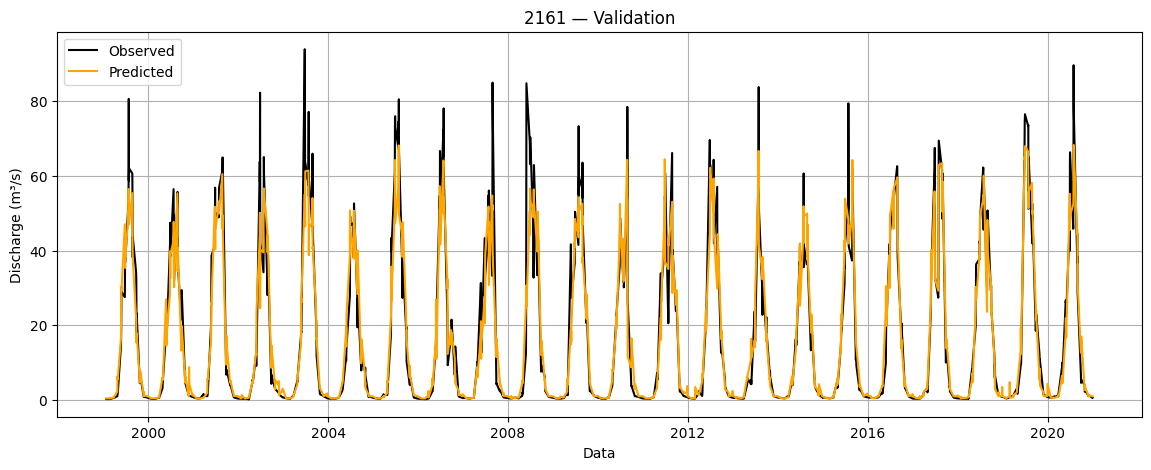

In [35]:
# Visualizing the predicted data vs observed
dates_test = data.loc[test_idx, "date"][data.loc[test_idx, "basin_id"]=="2161"]

df_plot = pd.DataFrame({
    "date": dates_test.values,
    "obs": y_test_b.values,
    "pred": pred_test
}).sort_values("date")

plt.figure(figsize=(14,5))
plt.plot(df_plot["date"], df_plot["obs"], label="Observed", color="black")
plt.plot(df_plot["date"], df_plot["pred"], label="Predicted", color="orange")
plt.title("2161 — Validation")
plt.xlabel("Data")
plt.ylabel("Discharge (m³/s)")
plt.legend()
plt.grid(True)
plt.show()


## **Random Forest - 2420**
### Hyperparameters Tuning - Manual

In [17]:
manual_tuning_results = {}
manual_tuned_models = {}

basin = "2420"

# Mask to include only the basin 2161
mask_train = data.loc[train_idx, "basin_id"] == basin
mask_val   = data.loc[val_idx,   "basin_id"] == basin

X_train_b = X_train[mask_train]
y_train_b = y_train[mask_train]

X_val_b = X_val[mask_val]
y_val_b = y_val[mask_val]

# Parameters grid
param_grid = {
    "n_estimators": [350, 400, 450],
    "max_depth": [15, 20, 25],
    "min_samples_leaf": [3, 4, 5],
    "max_features": ["sqrt", 0.7, 0.8, 0.9]
}

best_nse = -999
best_params = None

for n in param_grid["n_estimators"]:
    for d in param_grid["max_depth"]:
        for leaf in param_grid["min_samples_leaf"]:
            for mf in param_grid["max_features"]:

                model = RandomForestRegressor(
                    n_estimators=n,
                    max_depth=d,
                    min_samples_leaf=leaf,
                    max_features=mf,
                    n_jobs=-1,
                    random_state=42
                )

                model.fit(X_train_b, y_train_b)
                pred = model.predict(X_val_b)
                score = nse(y_val_b, pred)

                manual_tuning_results[(n, d, leaf, mf)] = score

                if score > best_nse:
                    best_nse = score
                    best_params = (n, d, leaf, mf)
                    manual_tuned_models[basin] = model

# Printing the best NSE with the respective best parameters
print("Best manual tuning NSE:", best_nse)
print("Best params:", best_params)


Best manual tuning NSE: 0.5267320356338269
Best params: (400, 20, 4, 0.9)


### Hyperparameters Tuning - Automatic

In [18]:
# Fixing NSE as the evaluation metric
nse_scorer = make_scorer(nse, greater_is_better=True)

# Selecting the basin
basin = "2420"

# Mask to include only the basin 2161
mask_train = data.loc[train_idx, "basin_id"] == basin
mask_val   = data.loc[val_idx,   "basin_id"] == basin

X_train_b = X_train[mask_train]
y_train_b = y_train[mask_train]

# Parameters grid based on manual results
param_dist = {
    "n_estimators": randint(385, 415),
    "max_depth": randint(18, 25),
    "min_samples_leaf": randint(3, 6),
    "max_features": [0.9, 1]
}

# Instantiate the RFR model
rf = RandomForestRegressor(
    n_jobs=-1,
    random_state=42
)

# Defining the RFR model
random_search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=30,
    scoring=nse_scorer,
    cv=3,
    verbose=1,
    random_state=42
)

# Fitting the data
random_search.fit(X_train_b, y_train_b)

# Printing the best NSE with the respective best parameters
print("Best NSE score:")
print(random_search.best_score_)

print("Best parameters (automatic):")
print(random_search.best_params_)

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best NSE score:
0.40429725226602103
Best parameters (automatic):
{'max_depth': 23, 'max_features': 0.9, 'min_samples_leaf': 5, 'n_estimators': 402}


### Final RFR Model

In [36]:
# Defining the best parameters for 2420 basin
best_params_2420 = {
    "n_estimators": 402,
    "max_depth": 23,
    "min_samples_leaf": 5,
    "max_features": 0.9
}

# RFR model for 2420
rf_final_2420 = RandomForestRegressor(
    **best_params_2420,
    n_jobs=-1,
    random_state=42
)

# Mask for train and validation
mask_train = (data.loc[train_idx, "basin_id"] == "2420")
mask_val   = (data.loc[val_idx,   "basin_id"] == "2420")
mask_test  = (data.loc[test_idx,  "basin_id"] == "2420")

X_train_b = X_train[mask_train]
y_train_b = y_train[mask_train]

X_val_b = X_val[mask_val]
y_val_b = y_val[mask_val]

X_test_b = X_test[mask_test]
y_test_b = y_test[mask_test]

# Training the model
rf_final_2420.fit(X_train_b, y_train_b)

# Predicting
pred_train = rf_final_2420.predict(X_train_b)
pred_val   = rf_final_2420.predict(X_val_b)
pred_test  = rf_final_2420.predict(X_test_b)

# Computing NSE
nse_train = nse(y_train_b, pred_train)
nse_val   = nse(y_val_b,   pred_val)
nse_test  = nse(y_test_b,  pred_test)

print("NSE Train:", nse_train)
print("NSE Val:  ", nse_val)
print("NSE Test:", nse_test)

NSE Train: 0.7663314022048977
NSE Val:   0.5244623640603298
NSE Test: 0.5186062905755079


In [37]:
# Saving the model
joblib.dump(rf_final_2420, "rf_model_2420.joblib")

['rf_model_2420.joblib']

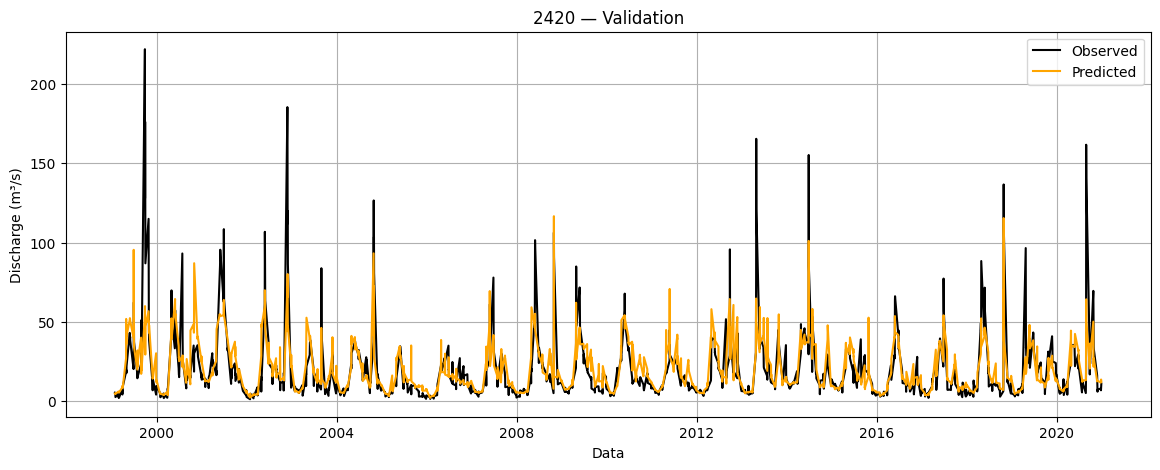

In [40]:
# Visualizing the predicted data vs observed
dates_test = data.loc[test_idx, "date"][data.loc[test_idx, "basin_id"]=="2420"]

df_plot = pd.DataFrame({
    "date": dates_test.values,
    "obs": y_test_b.values,
    "pred": pred_test
}).sort_values("date")

plt.figure(figsize=(14,5))
plt.plot(df_plot["date"], df_plot["obs"], label="Observed", color="black")
plt.plot(df_plot["date"], df_plot["pred"], label="Predicted", color="orange")
plt.title("2420 — Validation")
plt.xlabel("Data")
plt.ylabel("Discharge (m³/s)")
plt.legend()
plt.grid(True)
plt.show()

## **Random Forest - 2351**
### Hyperparameters Tuning - Manual

In [22]:
manual_tuning_results = {}
manual_tuned_models = {}

basin = "2351"

# Mask to include only the basin 2161
mask_train = data.loc[train_idx, "basin_id"] == basin
mask_val   = data.loc[val_idx,   "basin_id"] == basin

X_train_b = X_train[mask_train]
y_train_b = y_train[mask_train]

X_val_b = X_val[mask_val]
y_val_b = y_val[mask_val]

# Parameters grid
param_grid = {
    "n_estimators": [200, 300, 350, 400],
    "max_depth": [10, 15, 20, 25],
    "min_samples_leaf": [3, 4, 5],
    "max_features": ["sqrt", 0.7, 0.5]
}

best_nse = -999
best_params = None

for n in param_grid["n_estimators"]:
    for d in param_grid["max_depth"]:
        for leaf in param_grid["min_samples_leaf"]:
            for mf in param_grid["max_features"]:

                model = RandomForestRegressor(
                    n_estimators=n,
                    max_depth=d,
                    min_samples_leaf=leaf,
                    max_features=mf,
                    n_jobs=-1,
                    random_state=42
                )

                model.fit(X_train_b, y_train_b)
                pred = model.predict(X_val_b)
                score = nse(y_val_b, pred)

                manual_tuning_results[(n, d, leaf, mf)] = score

                if score > best_nse:
                    best_nse = score
                    best_params = (n, d, leaf, mf)
                    manual_tuned_models[basin] = model

# Printing the best NSE with the respective best parameters
print("Best manual tuning NSE:", best_nse)
print("Best params:", best_params)

Best manual tuning NSE: 0.7796953742382038
Best params: (200, 20, 3, 0.5)


### Hyperparameters Tuning - Automatic

In [23]:
# Fixing NSE as the evaluation metric
nse_scorer = make_scorer(nse, greater_is_better=True)

# Selecting the basin
basin = "2351"

# Mask to include only the basin 2161
mask_train = data.loc[train_idx, "basin_id"] == basin
mask_val   = data.loc[val_idx,   "basin_id"] == basin

X_train_b = X_train[mask_train]
y_train_b = y_train[mask_train]

# Parameters grid based on manual results
param_dist = {
    "n_estimators": randint(175, 250),
    "max_depth": randint(18, 23),
    "min_samples_leaf": randint(1, 4),
    "max_features": [0.3, 0.4, 0.5, 0.6]
}

# Instantiate the RFR model
rf = RandomForestRegressor(
    n_jobs=-1,
    random_state=42
)

# Defining the RFR model
random_search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=30,
    scoring=nse_scorer,
    cv=3,
    verbose=1,
    random_state=42
)

# Fitting the data
random_search.fit(X_train_b, y_train_b)

# Printing the best NSE with the respective best parameters
print("Best NSE score:")
print(random_search.best_score_)

print("Best parameters (automatic):")
print(random_search.best_params_)

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best NSE score:
0.628775575615581
Best parameters (automatic):
{'max_depth': 20, 'max_features': 0.5, 'min_samples_leaf': 3, 'n_estimators': 216}


### Final RFR Model

In [41]:
# Defining the best parameters for 2351 basin
best_params_2351 = {
    "n_estimators": 216,
    "max_depth": 20,
    "min_samples_leaf": 3,
    "max_features": 0.5
}

# RFR model for 2351
rf_final_2351 = RandomForestRegressor(
    **best_params_2351,
    n_jobs=-1,
    random_state=42
)

# Mask for train and validation
mask_train = (data.loc[train_idx, "basin_id"] == "2351")
mask_val   = (data.loc[val_idx,   "basin_id"] == "2351")
mask_test  = (data.loc[test_idx,  "basin_id"] == "2351")

X_train_b = X_train[mask_train]
y_train_b = y_train[mask_train]

X_val_b = X_val[mask_val]
y_val_b = y_val[mask_val]

X_test_b = X_test[mask_test]
y_test_b = y_test[mask_test]

# Training the model
rf_final_2351.fit(X_train_b, y_train_b)

# Predicting
pred_train = rf_final_2351.predict(X_train_b)
pred_val   = rf_final_2351.predict(X_val_b)
pred_test  = rf_final_2351.predict(X_test_b)

# Computing NSE
nse_train = nse(y_train_b, pred_train)
nse_val   = nse(y_val_b,   pred_val)
nse_test  = nse(y_test_b,  pred_test)

print("NSE Train:", nse_train)
print("NSE Val:  ", nse_val)
print("NSE Test:", nse_test)

NSE Train: 0.9036786274856269
NSE Val:   0.7786013786564271
NSE Test: 0.7127320234024205


In [55]:
# Saving the model
joblib.dump(rf_final_2351, "rf_model_2351.joblib")

['rf_model_2351.joblib']

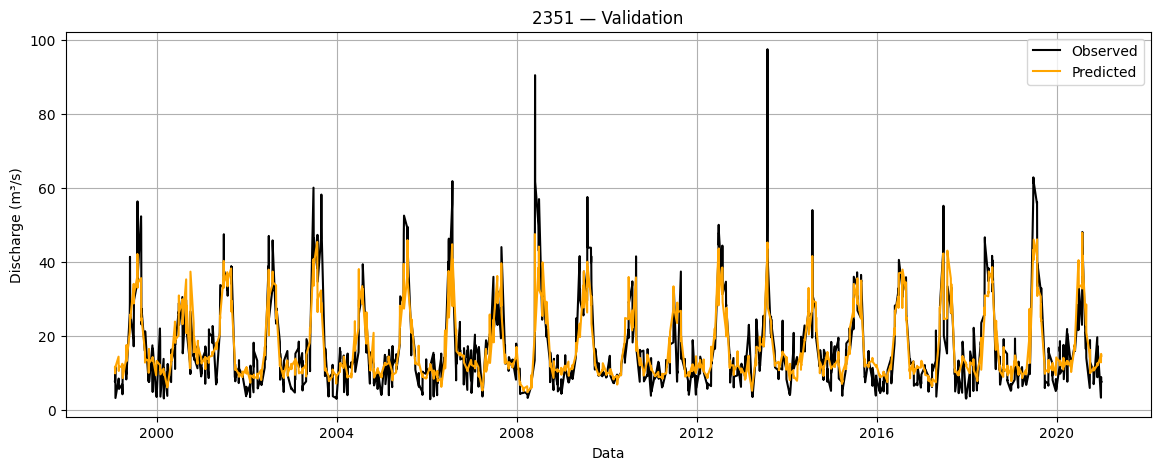

In [43]:
# Visualizing the predicted data vs observed
dates_test = data.loc[test_idx, "date"][data.loc[test_idx, "basin_id"]=="2351"]

df_plot = pd.DataFrame({
    "date": dates_test.values,
    "obs": y_test_b.values,
    "pred": pred_test
}).sort_values("date")

plt.figure(figsize=(14,5))
plt.plot(df_plot["date"], df_plot["obs"], label="Observed", color="black")
plt.plot(df_plot["date"], df_plot["pred"], label="Predicted", color="orange")
plt.title("2351 — Validation")
plt.xlabel("Data")
plt.ylabel("Discharge (m³/s)")
plt.legend()
plt.grid(True)
plt.show()

## **Cross-matrix**



=== Loading model trained on basin 2161 ===

=== Loading model trained on basin 2420 ===

=== Loading model trained on basin 2351 ===

====== CROSS-BASIN NSE MATRIX ======
       2161   2420   2351
2161  0.916 -0.622 -0.557
2420 -0.225  0.699 -2.763
2351  0.515  0.087  0.847


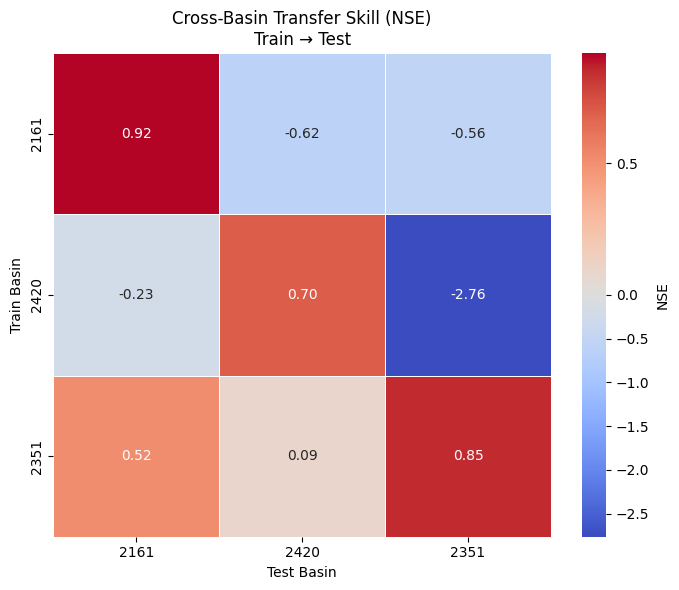


=== MODEL GENERALIZATION RANKING ===
2351: 0.571
2161: -0.095
2420: -1.092


In [49]:
# Matrice cross-basin (train basin → test basin)
cross_matrix = pd.DataFrame(
    index=catchments,
    columns=catchments,
    dtype=float
)

# Loop principale
for train_basin in catchments:

    print(f"\n=== Loading model trained on basin {train_basin} ===")

    # Load final RF model for this basin
    model = joblib.load(f"rf_model_{train_basin}.joblib")

    for test_basin in catchments:

        # selezione TUTTI i dati del bacino test_basin
        mask = (data["basin_id"] == test_basin)
        X_y = X[mask]
        y_y = y[mask]

        # Predizione
        pred_y = model.predict(X_y)

        # NSE
        cross_nse = nse(y_y, pred_y)

        cross_matrix.loc[train_basin, test_basin] = cross_nse

# Stampa ordinata
print("\n====== CROSS-BASIN NSE MATRIX ======")
print(cross_matrix.round(3))


import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import numpy as np

# Matrice NSE cross-basin → la tua cross_matrix
nse_df = cross_matrix.astype(float)

plt.figure(figsize=(7,6))

# Normalizzazione che centra la colormap su 0
norm = TwoSlopeNorm(
    vmin=nse_df.values.min(),   # valore NSE più basso (negativo)
    vcenter=0,                  # punto da marcare (separazione rosso/blu)
    vmax=nse_df.values.max()    # valore NSE più alto (idealmente vicino a 1)
)

sns.heatmap(
    nse_df,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",            # ottimo per divergenza negativo/positivo
    norm=norm,
    linewidths=0.5,
    cbar_kws={"label": "NSE"}
)

plt.title("Cross-Basin Transfer Skill (NSE)\nTrain → Test")
plt.xlabel("Test Basin")
plt.ylabel("Train Basin")
plt.tight_layout()
plt.show()


generalization_score = row_norm.mean(axis=1).sort_values(ascending=False)

print("\n=== MODEL GENERALIZATION RANKING ===")
for basin, score in generalization_score.items():
    print(f"{basin}: {score:.3f}")

# Prova


=== CROSS-BASIN MATRIX (raw) ===
       2161   2420   2351
2161  0.916 -0.622 -0.557
2420 -0.225  0.699 -2.763
2351  0.515  0.087  0.847

=== Row-normalized (generalization power) ===
       2161   2420   2351
2161  1.000 -0.678 -0.608
2420 -0.322  1.000 -3.954
2351  0.609  0.103  1.000

=== Column-normalized (basin difficulty) ===
       2161   2420   2351
2161  1.000 -0.889 -0.658
2420 -0.246  1.000 -3.264
2351  0.562  0.125  1.000

=== MODEL GENERALIZATION RANKING ===
2351: 0.571
2161: -0.095
2420: -1.092


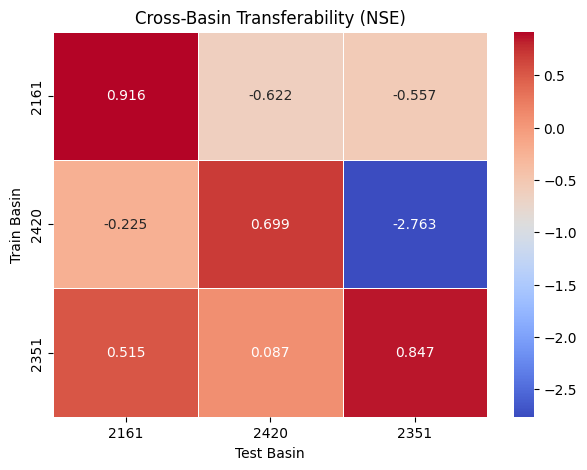

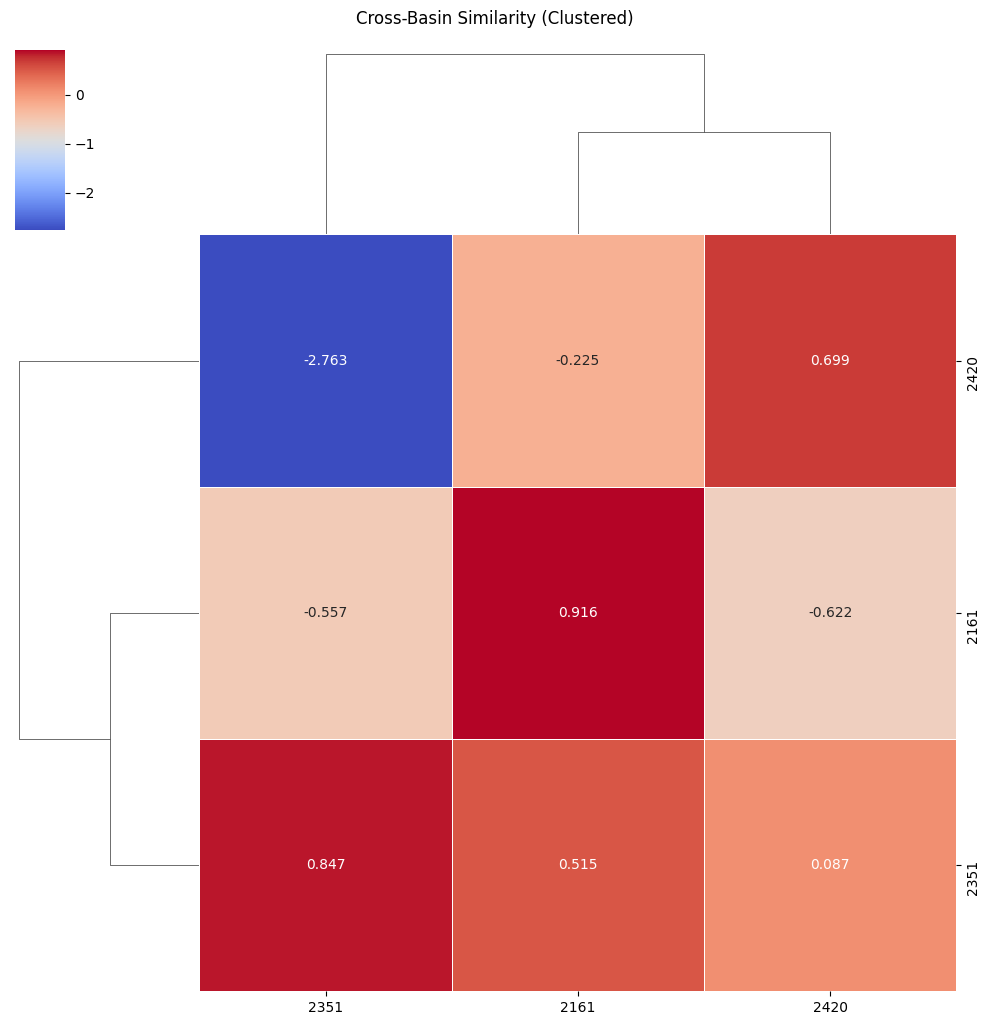

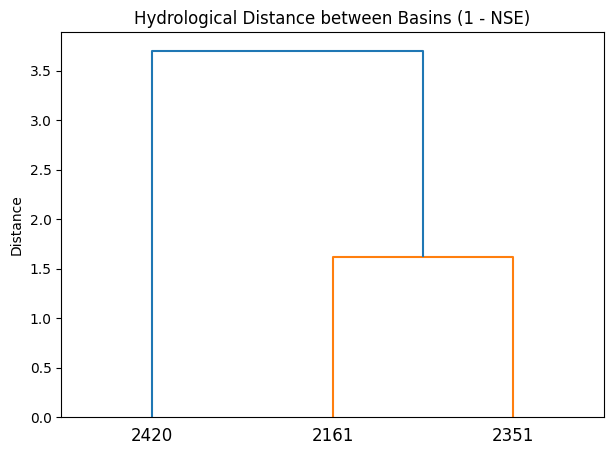


=== INTERPRETAZIONE AUTOMATICA ===
- Il modello addestrato su 2351 generalizza meglio sugli altri bacini.
- Il bacino più difficile da predire è 2351 (bassa trasferibilità).
- Due bacini clusterizzati vicini nel dendrogramma hanno comportamento idrologico simile.


In [47]:
import numpy as np
import pandas as pd
import joblib
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram

# ============================================
# 0) SETUP
# ============================================

catchments = ["2161", "2420", "2351"]

# Matrice cross-basin NSE train→test
cross = pd.DataFrame(index=catchments, columns=catchments, dtype=float)

# ============================================
# 1) COSTRUZIONE MATRICE NSE CROSS-BASIN
# ============================================

for train_basin in catchments:

    model = joblib.load(f"rf_model_{train_basin}.joblib")

    for test_basin in catchments:

        mask = (data["basin_id"] == test_basin)
        X_y = X[mask]
        y_y = y[mask]

        pred_y = model.predict(X_y)
        cross.loc[train_basin, test_basin] = nse(y_y, pred_y)


print("\n=== CROSS-BASIN MATRIX (raw) ===")
print(cross.round(3))


# ============================================
# 2) NORMALIZZAZIONE (RIGA E COLONNA)
# ============================================

# Normalizzazione per riga → "quanto generalizza un bacino verso gli altri"
row_norm = cross.div(cross.max(axis=1), axis=0)

# Normalizzazione per colonna → "quanto è difficile da predire un bacino"
col_norm = cross.div(cross.max(axis=0), axis=1)

print("\n=== Row-normalized (generalization power) ===")
print(row_norm.round(3))

print("\n=== Column-normalized (basin difficulty) ===")
print(col_norm.round(3))


# ============================================
# 3) MODEL RANKING (Quale bacino generalizza meglio?)
# ============================================

generalization_score = row_norm.mean(axis=1).sort_values(ascending=False)

print("\n=== MODEL GENERALIZATION RANKING ===")
for basin, score in generalization_score.items():
    print(f"{basin}: {score:.3f}")


# ============================================
# 4) HEATMAP AVANZATA (raw NSE)
# ============================================

plt.figure(figsize=(7,5))
sns.heatmap(cross.astype(float), annot=True, fmt=".3f",
            cmap="coolwarm", linewidths=0.5)
plt.title("Cross-Basin Transferability (NSE)")
plt.xlabel("Test Basin")
plt.ylabel("Train Basin")
plt.show()


# ============================================
# 5) CLUSTERMAP (cluster automatico)
# ============================================

sns.clustermap(
    cross.astype(float),
    cmap="coolwarm",
    annot=True,
    fmt=".3f",
    linewidths=0.5
)
plt.suptitle("Cross-Basin Similarity (Clustered)", y=1.02)
plt.show()


# ============================================
# 6) DENDROGRAMMA (distance = 1 - NSE)
# ============================================

# Convert NSE to "distance"
dist_matrix = 1 - cross.astype(float)

# Clustering gerarchico
link = linkage(dist_matrix, method="ward")

plt.figure(figsize=(7,5))
dendrogram(link, labels=catchments)
plt.title("Hydrological Distance between Basins (1 - NSE)")
plt.ylabel("Distance")
plt.show()


# ============================================
# 7) INTERPRETAZIONE AUTOMATICA (STAMPA)
# ============================================

print("\n=== INTERPRETAZIONE AUTOMATICA ===")

# Bacino più generalista → riga con valori alti
best_generalizer = generalization_score.index[0]
print(f"- Il modello addestrato su {best_generalizer} generalizza meglio sugli altri bacini.")

# Bacino più difficile da predire → colonna con valori bassi
difficulty_score = col_norm.mean(axis=0).sort_values()
hardest = difficulty_score.index[0]
print(f"- Il bacino più difficile da predire è {hardest} (bassa trasferibilità).")

# Similarità
print("- Due bacini clusterizzati vicini nel dendrogramma hanno comportamento idrologico simile.")


# Feature Importance


=== Basin 2161 — Feature Importance ===
                   feature  importance
2   temperature_mean(degC)    0.495543
17                     doy    0.172562
1    temperature_min(degC)    0.153971
16     ice_melt_index_year    0.051901
5                  swe(mm)    0.034382
14          melt_potential    0.034204
15              s_doy_year    0.029776
0      precipitation(mm/d)    0.010141
3    temperature_max(degC)    0.007888
4           rel_sun_dur(%)    0.006363
18                    year    0.000880
7         glac_vol_ch(km3)    0.000634
8         glac_mass_ch(Mt)    0.000615
19       glacier_area_frac    0.000581
6        glac_area_ch(km2)    0.000559
9                     area    0.000000
11                elev_min    0.000000
10               elev_mean    0.000000
12                elev_max    0.000000
13              slope_mean    0.000000


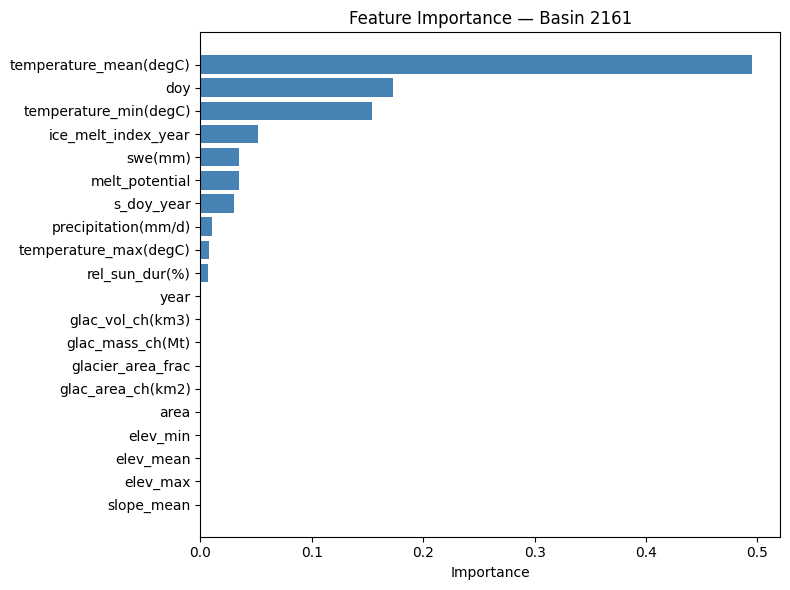


=== Basin 2420 — Feature Importance ===
                   feature  importance
1    temperature_min(degC)    0.209891
17                     doy    0.191502
5                  swe(mm)    0.180199
0      precipitation(mm/d)    0.175945
3    temperature_max(degC)    0.042540
4           rel_sun_dur(%)    0.032282
2   temperature_mean(degC)    0.028592
18                    year    0.025608
16     ice_melt_index_year    0.022264
14          melt_potential    0.019816
15              s_doy_year    0.019634
8         glac_mass_ch(Mt)    0.013953
7         glac_vol_ch(km3)    0.012801
19       glacier_area_frac    0.012645
6        glac_area_ch(km2)    0.012328
9                     area    0.000000
11                elev_min    0.000000
10               elev_mean    0.000000
12                elev_max    0.000000
13              slope_mean    0.000000


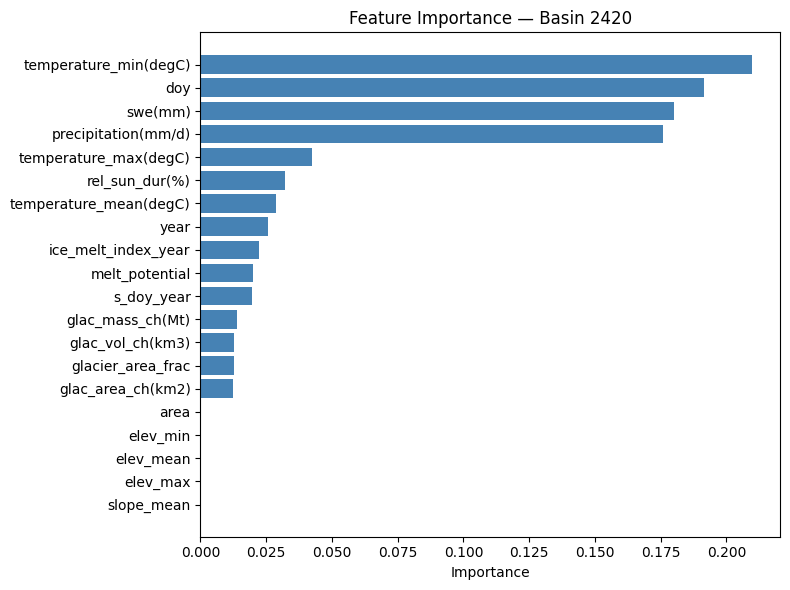


=== Basin 2351 — Feature Importance ===
                   feature  importance
1    temperature_min(degC)    0.294642
17                     doy    0.166949
2   temperature_mean(degC)    0.160982
5                  swe(mm)    0.095880
16     ice_melt_index_year    0.049520
0      precipitation(mm/d)    0.042930
14          melt_potential    0.041116
3    temperature_max(degC)    0.030621
15              s_doy_year    0.029578
4           rel_sun_dur(%)    0.026483
18                    year    0.014190
7         glac_vol_ch(km3)    0.011946
19       glacier_area_frac    0.011906
8         glac_mass_ch(Mt)    0.011875
6        glac_area_ch(km2)    0.011381
9                     area    0.000000
11                elev_min    0.000000
10               elev_mean    0.000000
12                elev_max    0.000000
13              slope_mean    0.000000


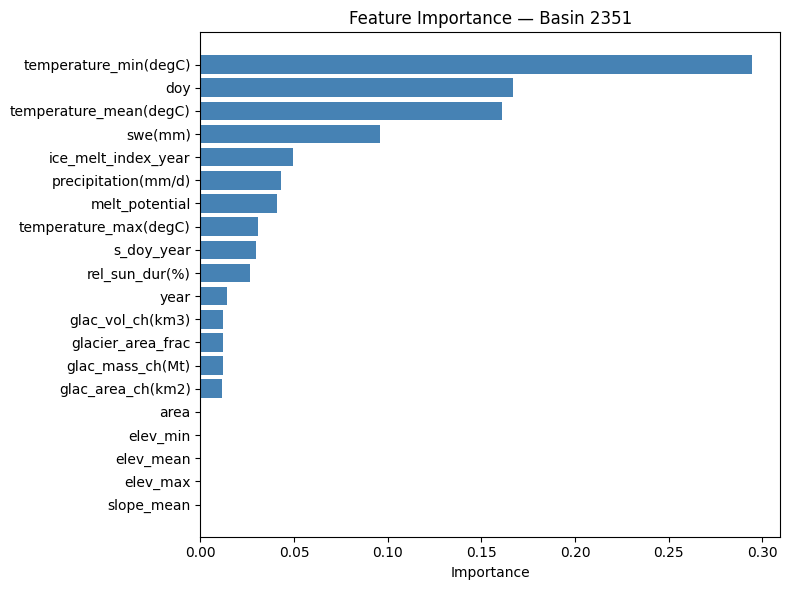

In [50]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt

catchments = ["2161", "2420", "2351"]
feature_importances = {}   # per salvarle tutte

for basin in catchments:

    print(f"\n=== Basin {basin} — Feature Importance ===")

    # Load model
    model = joblib.load(f"rf_model_{basin}.joblib")

    # Extract feature importances
    importances = model.feature_importances_
    features = X.columns

    df_imp = pd.DataFrame({
        "feature": features,
        "importance": importances
    }).sort_values("importance", ascending=False)

    feature_importances[basin] = df_imp   # store for next step

    print(df_imp)

    # Plot barplot for this basin
    plt.figure(figsize=(8,6))
    plt.barh(df_imp["feature"], df_imp["importance"], color="steelblue")
    plt.gca().invert_yaxis()
    plt.title(f"Feature Importance — Basin {basin}")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()



=== Combined Feature Importance Table ===
                   feature      2161      2420      2351
0   temperature_mean(degC)  0.495543  0.209891  0.294642
1                      doy  0.172562  0.191502  0.166949
2    temperature_min(degC)  0.153971  0.180199  0.160982
3      ice_melt_index_year  0.051901  0.175945  0.095880
4                  swe(mm)  0.034382  0.042540  0.049520
5           melt_potential  0.034204  0.032282  0.042930
6               s_doy_year  0.029776  0.028592  0.041116
7      precipitation(mm/d)  0.010141  0.025608  0.030621
8    temperature_max(degC)  0.007888  0.022264  0.029578
9           rel_sun_dur(%)  0.006363  0.019816  0.026483
10                    year  0.000880  0.019634  0.014190
11        glac_vol_ch(km3)  0.000634  0.013953  0.011946
12        glac_mass_ch(Mt)  0.000615  0.012801  0.011906
13       glacier_area_frac  0.000581  0.012645  0.011875
14       glac_area_ch(km2)  0.000559  0.012328  0.011381
15                    area  0.000000  0.00000

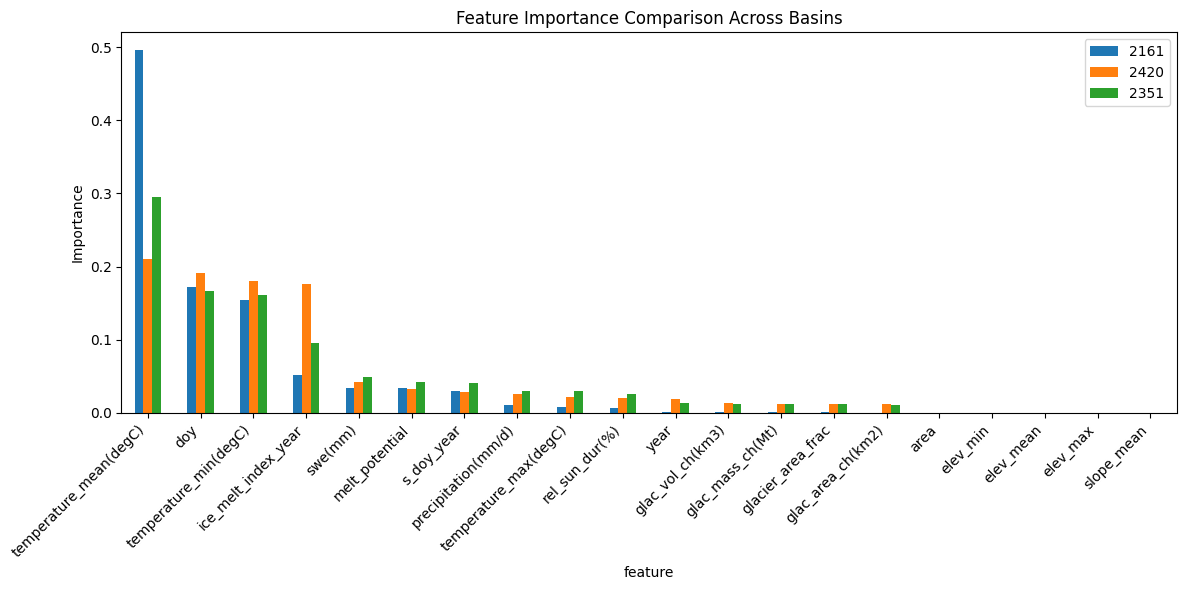

In [51]:
# Combine all feature importances in one table
all_features = feature_importances[catchments[0]]["feature"].values

comparison_df = pd.DataFrame({"feature": all_features})

for basin in catchments:
    comparison_df[basin] = feature_importances[basin]["importance"].values

# Show table
print("\n=== Combined Feature Importance Table ===")
print(comparison_df)

# Plot comparative bar chart
comparison_df.set_index("feature").plot(kind="bar", figsize=(12,6))
plt.title("Feature Importance Comparison Across Basins")
plt.ylabel("Importance")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()



=== PDP for Basin 2161 — ice_melt_index_year ===


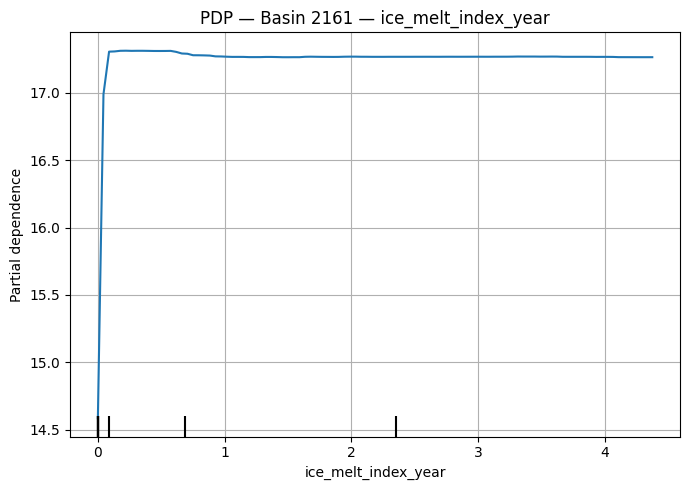


=== PDP for Basin 2351 — swe(mm) ===


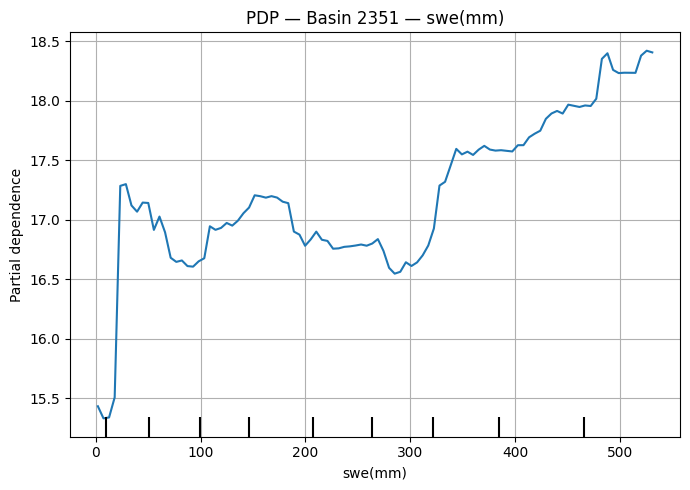


=== PDP for Basin 2420 — precipitation(mm/d) ===


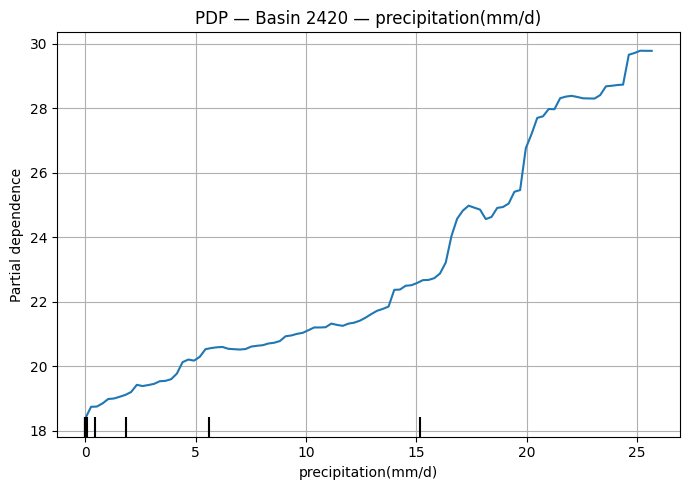

In [54]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt
import joblib

# Feature scelte secondo il regime idrologico
pdp_features = {
    "2161": "ice_melt_index_year",   # Glaciale
    "2351": "swe(mm)",               # Nivo-glaciale / Alpino
    "2420": "precipitation(mm/d)"    # Nivo-pluviale / Pluviale-dominante
}

for basin in ["2161", "2351", "2420"]:
    print(f"\n=== PDP for Basin {basin} — {pdp_features[basin]} ===")

    model = joblib.load(f"rf_model_{basin}.joblib")

    mask_train = data.loc[train_idx, "basin_id"] == basin
    X_train_b = X_train[mask_train]

    feature = pdp_features[basin]

    fig, ax = plt.subplots(figsize=(7,5))
    PartialDependenceDisplay.from_estimator(
        model,
        X_train_b,
        [feature],
        ax=ax
    )

    plt.title(f"PDP — Basin {basin} — {feature}")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


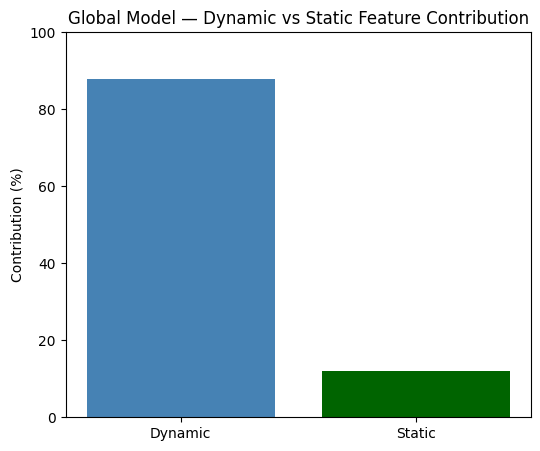

Dynamic Importance %: 87.91444344926738
Static Importance %: 12.08555655073261


In [57]:
import numpy as np
import matplotlib.pyplot as plt

# Lista variabili
dynamic_vars = [
    "precipitation(mm/d)",
    "temperature_min(degC)",
    "temperature_mean(degC)",
    "temperature_max(degC)",
    "rel_sun_dur(%)",
    "swe(mm)",
    "ice_melt_index_year"
]

static_vars = [
    "glac_area_ch(km2)",
    "glac_vol_ch(km3)",
    "glac_mass_ch(Mt)",
    "area",
    "elev_mean",
    "elev_min",
    "elev_max",
    "slope_mean"
]

# Calcolo importanza totale
fi = df_fi_global.set_index("feature")["importance"]

dynamic_importance = fi[dynamic_vars].sum()
static_importance  = fi[static_vars].sum()

# Normalizzazione in percentuale
total = dynamic_importance + static_importance
dynamic_pct = dynamic_importance / total * 100
static_pct  = static_importance  / total * 100

# Plot
plt.figure(figsize=(6,5))
plt.bar(["Dynamic", "Static"], [dynamic_pct, static_pct], color=["steelblue", "darkgreen"])
plt.ylabel("Contribution (%)")
plt.title("Global Model — Dynamic vs Static Feature Contribution")
plt.ylim(0, 100)
plt.show()

print("Dynamic Importance %:", dynamic_pct)
print("Static Importance %:", static_pct)


   glac_area_ch(km2)  glac_vol_ch(km3)  glac_mass_ch(Mt)   area  elev_mean  \
0           118.1677          15.53050         13200.928  195.5    2929.36   
1           207.9369          14.04852         11941.245  785.8    2641.94   
2             0.4733           0.01426            12.121  471.9    1667.39   

   elev_min  elev_max  slope_mean  glacier_area_frac basin_id       NSE  
0   1472.64   4088.80       23.32           0.604438     2161  0.899480  
1    657.93   4521.34       26.98           0.264618     2351  0.684923  
2    243.63   3169.93       30.29           0.001003     2420  0.542386  

=== Meta-Model Feature Importance ===
             feature  importance
1   glac_vol_ch(km3)    0.201296
8  glacier_area_frac    0.177352
2   glac_mass_ch(Mt)    0.143261
4          elev_mean    0.134577
5           elev_min    0.122321
0  glac_area_ch(km2)    0.097161
3               area    0.053493
7         slope_mean    0.038557
6           elev_max    0.031982


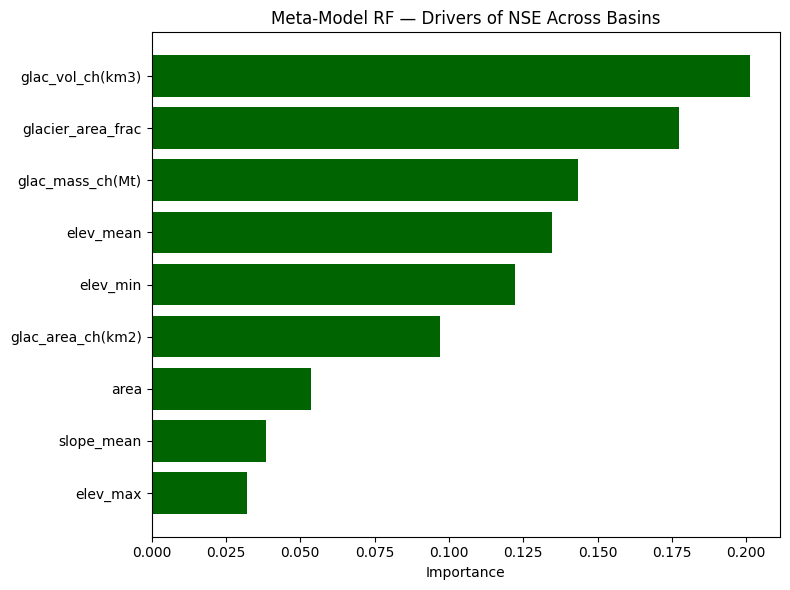

In [59]:
import pandas as pd

# Statiche (values identical within each basin)
static_cols = [
    "glac_area_ch(km2)",
    "glac_vol_ch(km3)",
    "glac_mass_ch(Mt)",
    "area",
    "elev_mean",
    "elev_min",
    "elev_max",
    "slope_mean",
    "glacier_area_frac"
]

meta_rows = []

for basin in ["2161", "2351", "2420"]:
    df_b = final_df[final_df["basin_id"] == basin]

    # NSE finale del bacino (usa il tuo NSE di test!)
    nse_value = baseline_results[basin]["test_nse"]

    # Statiche estratte una volta
    row = df_b[static_cols].iloc[0].to_dict()
    row["basin_id"] = basin
    row["NSE"] = nse_value

    meta_rows.append(row)

meta_df = pd.DataFrame(meta_rows)
print(meta_df)


from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

X_meta = meta_df[static_cols]
y_meta = meta_df["NSE"]

# Random Forest per vedere importanze
rf_meta = RandomForestRegressor(n_estimators=200, random_state=42)
rf_meta.fit(X_meta, y_meta)

fi_meta = pd.DataFrame({
    "feature": static_cols,
    "importance": rf_meta.feature_importances_
}).sort_values("importance", ascending=False)

print("\n=== Meta-Model Feature Importance ===")
print(fi_meta)

# Plot
plt.figure(figsize=(8,6))
plt.barh(fi_meta["feature"], fi_meta["importance"], color="darkgreen")
plt.gca().invert_yaxis()
plt.title("Meta-Model RF — Drivers of NSE Across Basins")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()



In [19]:
import joblib
import matplotlib.pyplot as plt
import pandas as pd

# -------------------------------
#  BASINS & MODEL FILES
# -------------------------------
basins = ["2161", "2420", "2351"]
model_files = {
    "2161": "rf_model_2161.joblib",
    "2420": "rf_model_2420.joblib",
    "2351": "rf_model_2351.joblib"
}

# -------------------------------
#  FEATURE GROUPS
# -------------------------------
dynamic_time = [
    "precipitation(mm/d)",
    "temperature_min(degC)",
    "temperature_mean(degC)",
    "temperature_max(degC)",
    "rel_sun_dur(%)",
    "swe(mm)",
    "melt_potential",
    "s_doy_year",
    "ice_melt_index_year",
    "doy",
    "year"
]

static_vars = [
    "glac_area_ch(km2)",
    "glac_vol_ch(km3)",
    "glac_mass_ch(Mt)",
    "area",
    "elev_min",
    "elev_mean",
    "elev_max",
    "slope_mean",
    "glacier_area_frac"
]


# -------------------------------
#  LOOP
# -------------------------------
for basin in basins:

    print(f"\n=== BASIN {basin} ===")

    # Load model
    model = joblib.load(model_files[basin])

    # Compute FI
    fi = pd.DataFrame({
        "feature": predictors,
        "importance": model.feature_importances_
    })

    # -------------------------
    # 1) TOP 8 DYNAMIC FEATURES
    # -------------------------
    fi_dyn = fi[fi["feature"].isin(dynamic_time)].copy()
    fi_dyn = fi_dyn.sort_values("importance", ascending=False).head(8)

    plt.figure(figsize=(6,4))
    plt.barh(fi_dyn["feature"], fi_dyn["importance"], color="steelblue")
    plt.gca().invert_yaxis()
    plt.title(f"Basin {basin} — Top 8 Dynamic Features")
    plt.xlabel("Importance")
    plt.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()

    # -------------------------
    # 2) STATIC FEATURES (NORMALIZED)
    # -------------------------
    fi_static = fi[fi["feature"].isin(static_vars)].copy()
    fi_static["importance_norm"] = fi_static["importance"] / fi_static["importance"].sum()

    plt.figure(figsize=(6,4))
    plt.barh(fi_static["feature"], fi_static["importance_norm"], color="darkorange")
    plt.gca().invert_yaxis()
    plt.title(f"Basin {basin} — Static Features (Normalized)")
    plt.xlabel("Relative Importance (Sum = 1)")
    plt.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()



NameError: name 'rf_final_2161' is not defined

In [20]:
import os
os.listdir()


['.config', 'drive', 'sample_data']